# 07 — Statistical trends and change-point diagnostics
**Purpose:** quantify long-term trends, seasonally adjusted correlations, lagged relationships, decomposition, and structural-change candidates before machine learning.  
**Inputs:** `outputs/tables/langtang_monthly_features.csv` from notebook 06.  
**Outputs:** trend/correlation/change-point tables and publication-quality diagnostic charts.  
**Runtime:** typically under five minutes; no Earth Engine request is required.  
**Dependencies:** completed notebook 06 and packages in `requirements.txt`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'
%pip -q install -r requirements.txt


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.9 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from src.config import SETTINGS
from src.trend_analysis import (
    ANALYSIS_FEATURES, build_trend_analysis_matrix, build_trend_summary,
    correlation_tables, detect_change_points, lagged_correlations,
    load_integrated_features, multivariate_snow_regression,
    stl_decomposition, trend_quality_sensitivity,
)
from src.utils import ensure_output_directories
from src.visualization import (
    plot_change_points, plot_correlation_heatmap, plot_trend_panels,
)
ensure_output_directories()


## Load and seasonally adjust
Temperature and precipitation use anomalies already generated from their historical seasonal baselines. PDD is demeaned by calendar month. Optical and SAR variables use same-calendar-month anomalies and retain all missing observations.

In [3]:
feature_path = SETTINGS.output_tables / 'langtang_monthly_features.csv'
features = load_integrated_features(feature_path)
analysis = build_trend_analysis_matrix(features)
print('Period:', analysis['date'].min(), 'to', analysis['date'].max())
display(analysis.tail(18))


Period: 2015-07-01 00:00:00 to 2026-08-01 00:00:00


,date,temp_anomaly,precip_anomaly,PDD_adjusted,snow_fraction_anomaly,NDSI_anomaly,VV_anomaly,VH_anomaly
116,2025-03-01,0.558191,-0.597698,-0.291726,0.035833,0.037376,-1.121258,-1.916637
117,2025-04-01,1.275408,0.451284,-0.460083,-0.134932,-0.131377,0.452013,0.359568
118,2025-05-01,1.416435,0.527653,36.530463,-0.154373,-0.146641,0.015359,-0.446947
119,2025-06-01,0.385120,1.454152,10.661828,0.013943,0.019446,-0.051891,-0.275795
120,2025-07-01,0.768242,-0.893096,15.173224,-0.137282,-0.105653,0.047151,-0.120339
121,2025-08-01,0.609156,0.176509,5.558929,0.023664,-0.004291,-0.186517,-0.328273
122,2025-09-01,1.233182,0.388635,19.040935,-0.067270,-0.038691,-0.327583,-0.864191
123,2025-10-01,0.361146,2.925317,-16.191437,0.064645,0.059933,-0.620137,-1.097053
124,2025-11-01,-0.173294,-0.244817,-0.513563,0.219003,0.232674,-0.985139,-1.564880
125,2025-12-01,1.687053,-1.189120,-0.657406,0.034767,0.028017,-0.306318,-0.472512


## OLS-HAC, Mann–Kendall, and Sen slope
OLS uncertainty uses a heteroskedasticity/autocorrelation-consistent covariance estimate with up to 12 lags. Mann–Kendall is reported as the original test and can still be affected by serial correlation. Sen slopes and 95% intervals are expressed per year. Multiple comparisons are not adjusted in this exploratory table.

,feature,n,start,end,ols_slope_per_year,ols_hac_se,ols_p_value,ols_r_squared,sen_slope_per_year,sen_ci_low,sen_ci_high,mk_trend,mk_tau,mk_p_value,mk_significant_0_05,modified_mk_trend,modified_mk_p_value,modified_mk_significant_0_05,lag1_autocorrelation,ljung_box_p_value
0,temp_anomaly,133,2015-07-01,2026-07-01,0.045749,0.042432,2.809503e-01,0.012718,0.063518,0.004250,0.113499,increasing,0.123718,3.482234e-02,True,no trend,1.336629e-01,False,0.428874,1.679114e-04
1,precip_anomaly,133,2015-07-01,2026-07-01,0.031040,0.021377,1.464987e-01,0.008053,0.027874,-0.026000,0.083132,no trend,0.054910,3.494862e-01,False,no trend,3.101941e-01,False,0.086319,8.738070e-01
2,PDD_adjusted,133,2015-07-01,2026-07-01,0.839416,0.373683,2.468283e-02,0.048710,0.359352,0.055842,0.918693,increasing,0.171110,3.475815e-03,True,increasing,1.385775e-02,True,0.318976,1.509758e-02
3,snow_fraction_anomaly,104,2017-04-01,2026-08-01,-0.014041,0.008074,8.201714e-02,0.069376,-0.013319,-0.023849,-0.004186,decreasing,-0.182226,6.171656e-03,True,no trend,6.581152e-02,False,0.554869,3.977433e-08
4,NDSI_anomaly,104,2017-04-01,2026-08-01,-0.012602,0.007649,9.945272e-02,0.069680,-0.012972,-0.022505,-0.003700,decreasing,-0.188200,4.678149e-03,True,no trend,6.111966e-02,False,0.601493,3.232130e-10
5,VV_anomaly,116,2015-10-01,2026-08-01,-0.071821,0.018430,9.737204e-05,0.198981,-0.057934,-0.081179,-0.035714,decreasing,-0.310645,7.749910e-07,True,decreasing,7.059158e-06,True,0.314018,9.637524e-05
6,VH_anomaly,116,2015-10-01,2026-08-01,-0.149604,0.026858,2.543623e-08,0.321222,-0.129939,-0.168419,-0.093602,decreasing,-0.409595,7.202816e-11,True,decreasing,2.502860e-07,True,0.483287,2.254567e-17


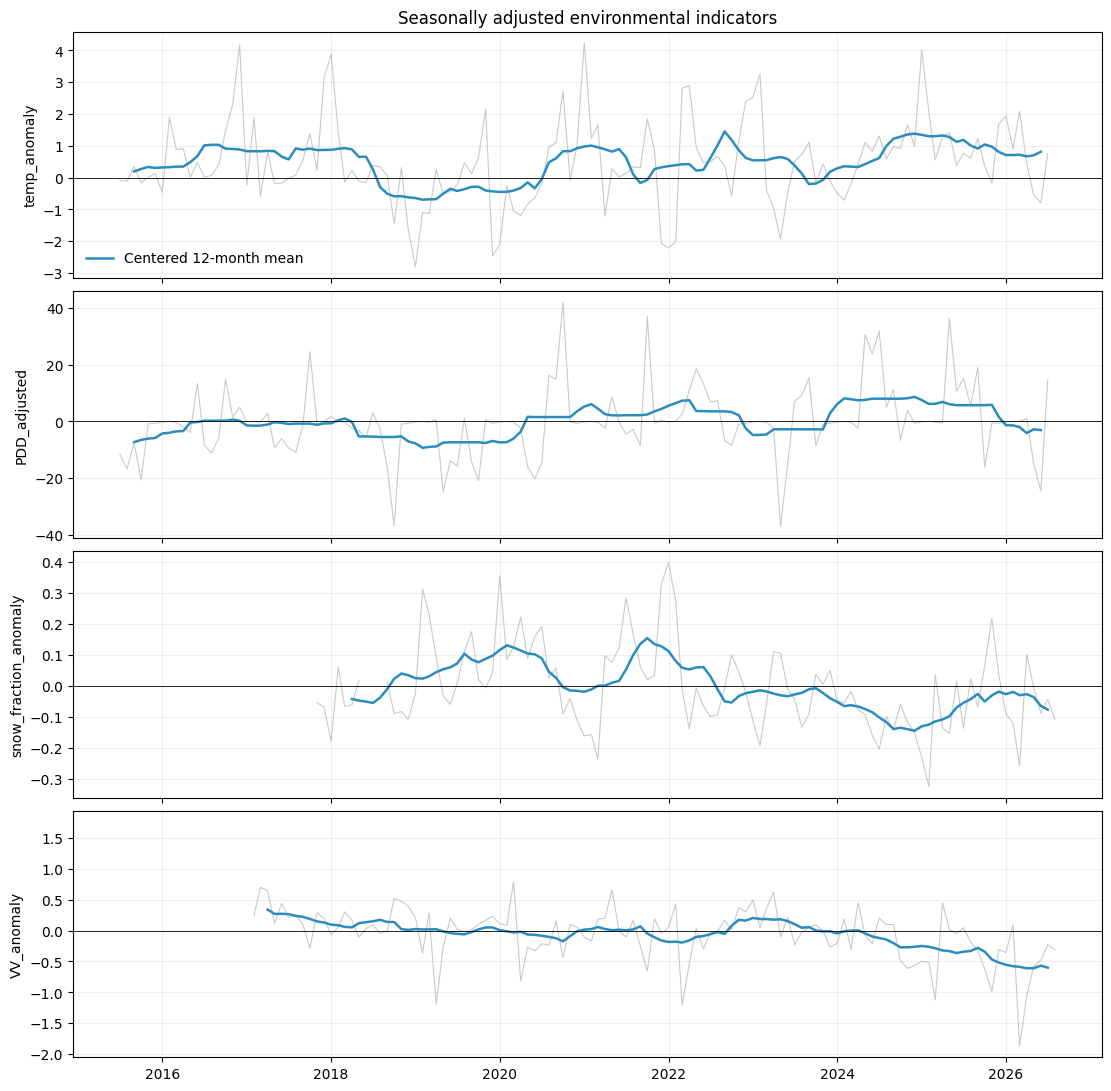

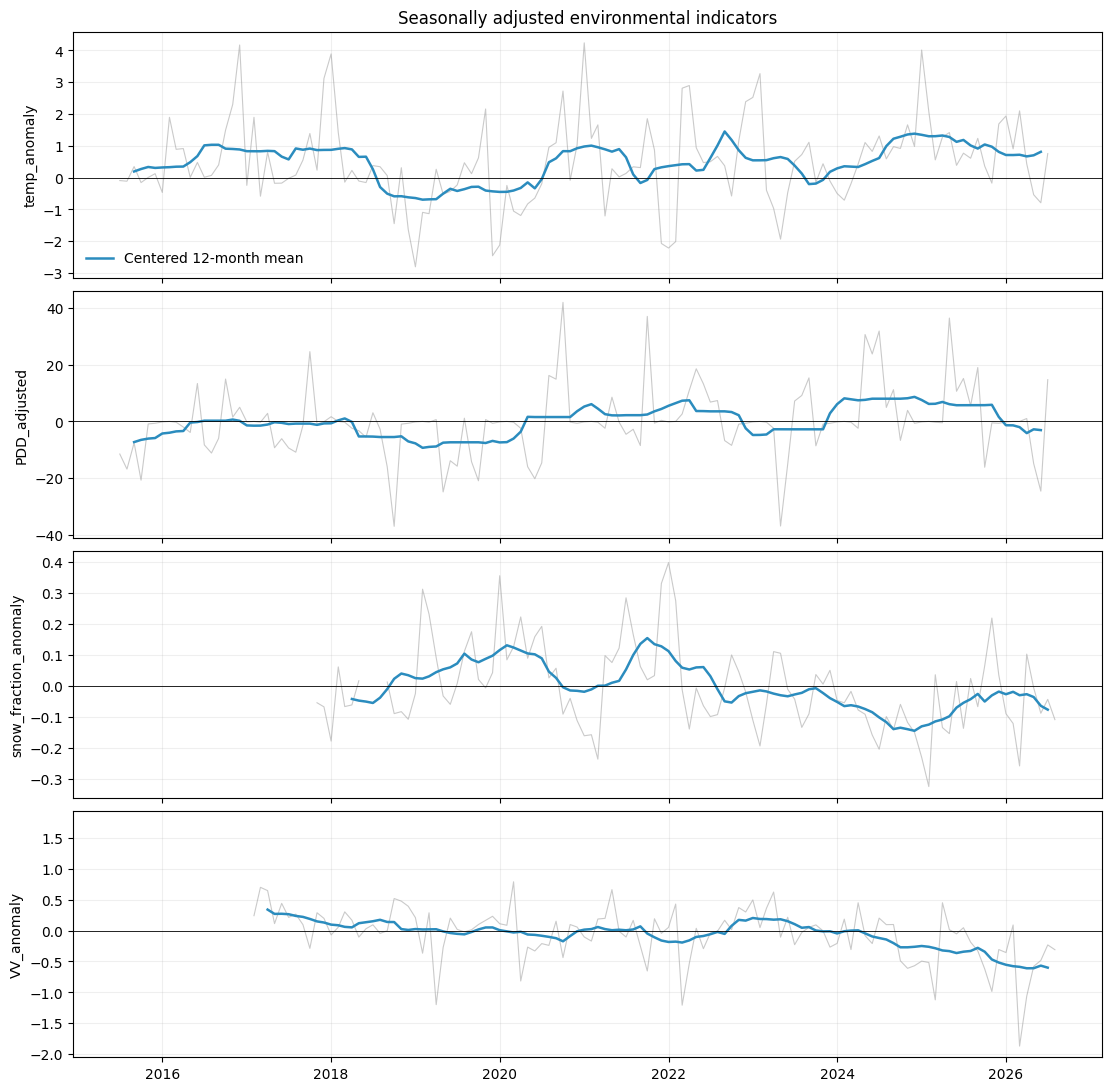

In [4]:
trend_summary = build_trend_summary(analysis)
trend_path = SETTINGS.output_tables / 'trend_summary.csv'
trend_summary.to_csv(trend_path, index=False)
display(trend_summary)
trend_figure = plot_trend_panels(
    analysis, SETTINGS.output_charts / 'seasonally_adjusted_trends.png'
)
trend_figure


## Pairwise and lagged correlations
Pairwise calculations use only mutually observed months and report pair counts. In lagged tables, a positive lag means the proposed driver precedes the response. Correlation is descriptive and is not evidence of causation.

,temp_anomaly,precip_anomaly,PDD_adjusted,snow_fraction_anomaly,NDSI_anomaly,VV_anomaly,VH_anomaly
temp_anomaly,1.000000,-0.261878,0.396200,-0.616619,-0.602523,-0.238698,-0.295122
precip_anomaly,-0.261878,1.000000,0.121941,0.324198,0.317040,-0.057650,-0.097446
PDD_adjusted,0.396200,0.121941,1.000000,-0.249172,-0.251768,-0.131677,-0.210878
snow_fraction_anomaly,-0.616619,0.324198,-0.249172,1.000000,0.989530,0.038686,0.099197
NDSI_anomaly,-0.602523,0.317040,-0.251768,0.989530,1.000000,0.014229,0.071296
VV_anomaly,-0.238698,-0.057650,-0.131677,0.038686,0.014229,1.000000,0.946946
VH_anomaly,-0.295122,-0.097446,-0.210878,0.099197,0.071296,0.946946,1.000000


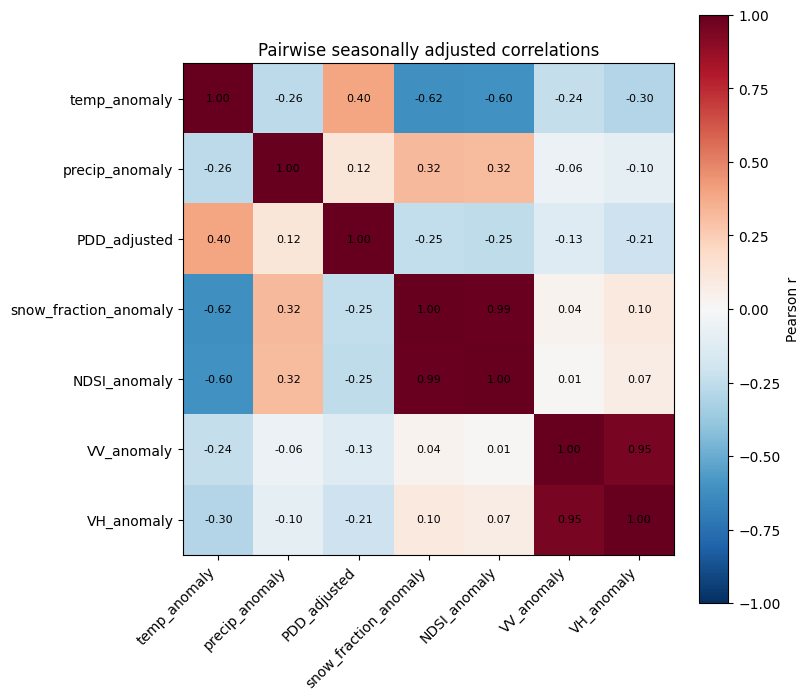

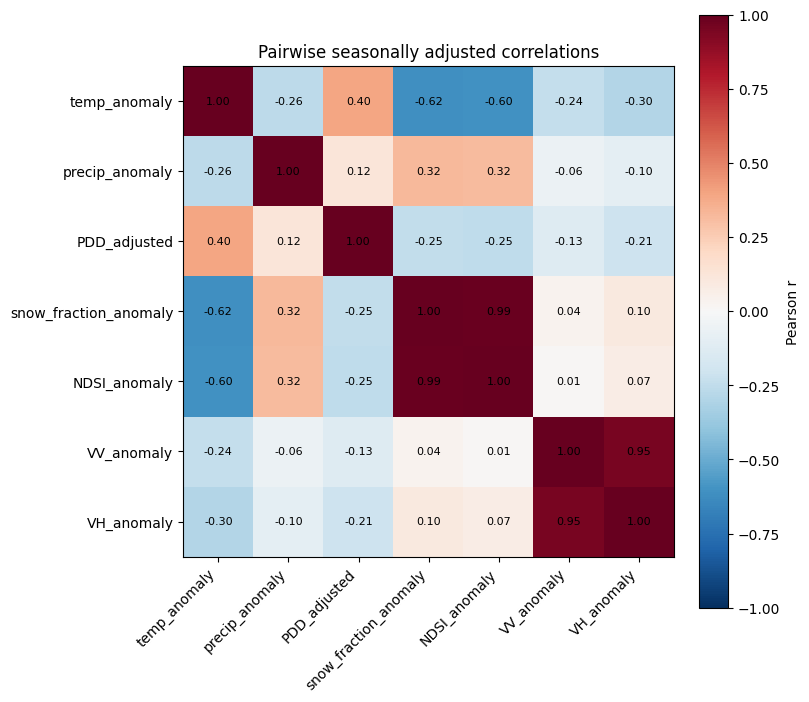

In [5]:
pearson, spearman, pair_counts = correlation_tables(analysis)
pearson.to_csv(SETTINGS.output_tables / 'correlation_pearson.csv')
spearman.to_csv(SETTINGS.output_tables / 'correlation_spearman.csv')
pair_counts.to_csv(SETTINGS.output_tables / 'correlation_pair_counts.csv')
display(pearson)
correlation_figure = plot_correlation_heatmap(
    pearson, SETTINGS.output_charts / 'correlation_heatmap.png'
)
correlation_figure


In [6]:
lagged = pd.concat([
    lagged_correlations(analysis, 'temp_anomaly', 'snow_fraction_anomaly'),
    lagged_correlations(analysis, 'PDD_adjusted', 'snow_fraction_anomaly'),
    lagged_correlations(analysis, 'precip_anomaly', 'VV_anomaly'),
] , ignore_index=True)
lagged.to_csv(SETTINGS.output_tables / 'lagged_correlations.csv', index=False)
display(lagged)


,driver,response,lag_months,n_pairs,pearson_r,p_value,p_value_fdr_bh,significant_fdr_0_05,lag_definition
0,temp_anomaly,snow_fraction_anomaly,0,103,-0.616619,4.074651e-12,5.297047e-11,True,response(t) versus driver(t-lag); positive=dri...
1,temp_anomaly,snow_fraction_anomaly,1,104,-0.498781,7.094084e-08,4.611154e-07,True,response(t) versus driver(t-lag); positive=dri...
2,temp_anomaly,snow_fraction_anomaly,2,104,-0.258295,8.112529e-03,3.515429e-02,True,response(t) versus driver(t-lag); positive=dri...
3,temp_anomaly,snow_fraction_anomaly,3,104,-0.152655,1.218521e-01,3.960195e-01,False,response(t) versus driver(t-lag); positive=dri...
4,temp_anomaly,snow_fraction_anomaly,4,104,-0.067940,4.931701e-01,8.055203e-01,False,response(t) versus driver(t-lag); positive=dri...
5,temp_anomaly,snow_fraction_anomaly,5,104,-0.070697,4.757517e-01,8.055203e-01,False,response(t) versus driver(t-lag); positive=dri...
6,temp_anomaly,snow_fraction_anomaly,6,104,-0.058146,5.576679e-01,8.055203e-01,False,response(t) versus driver(t-lag); positive=dri...
7,temp_anomaly,snow_fraction_anomaly,7,104,-0.020460,8.366729e-01,9.063956e-01,False,response(t) versus driver(t-lag); positive=dri...
8,temp_anomaly,snow_fraction_anomaly,8,104,-0.066137,5.047447e-01,8.055203e-01,False,response(t) versus driver(t-lag); positive=dri...
9,temp_anomaly,snow_fraction_anomaly,9,104,-0.025988,7.934246e-01,9.063956e-01,False,response(t) versus driver(t-lag); positive=dri...


## STL decomposition
STL is run only on the complete raw regional temperature series. The function refuses internal gaps rather than interpolating them.

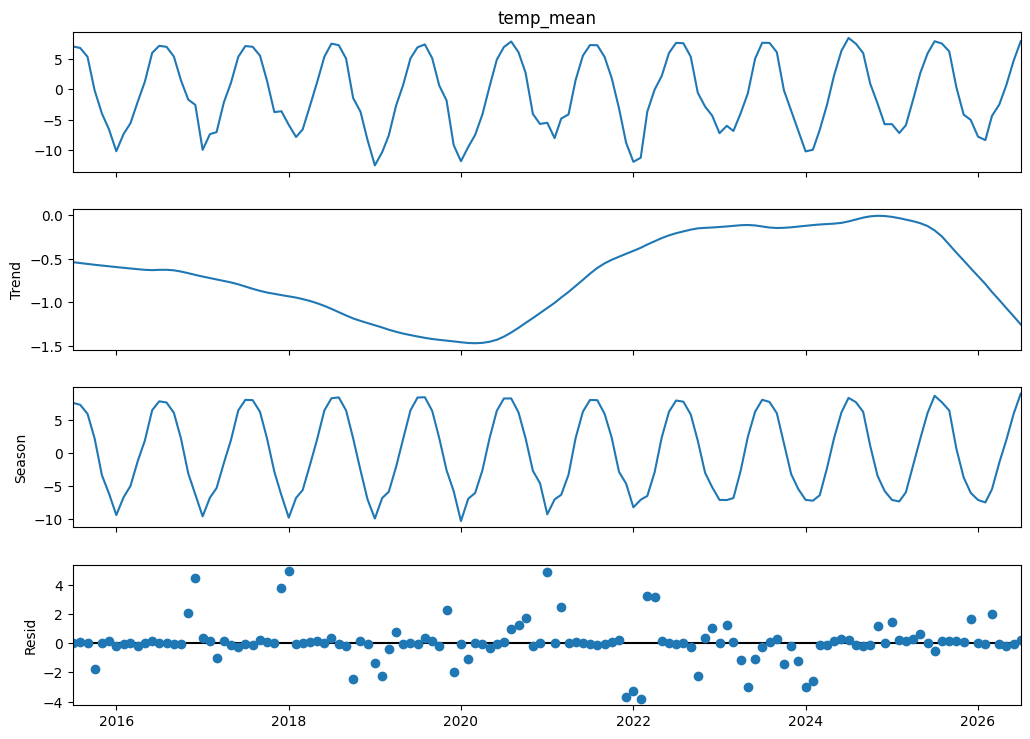

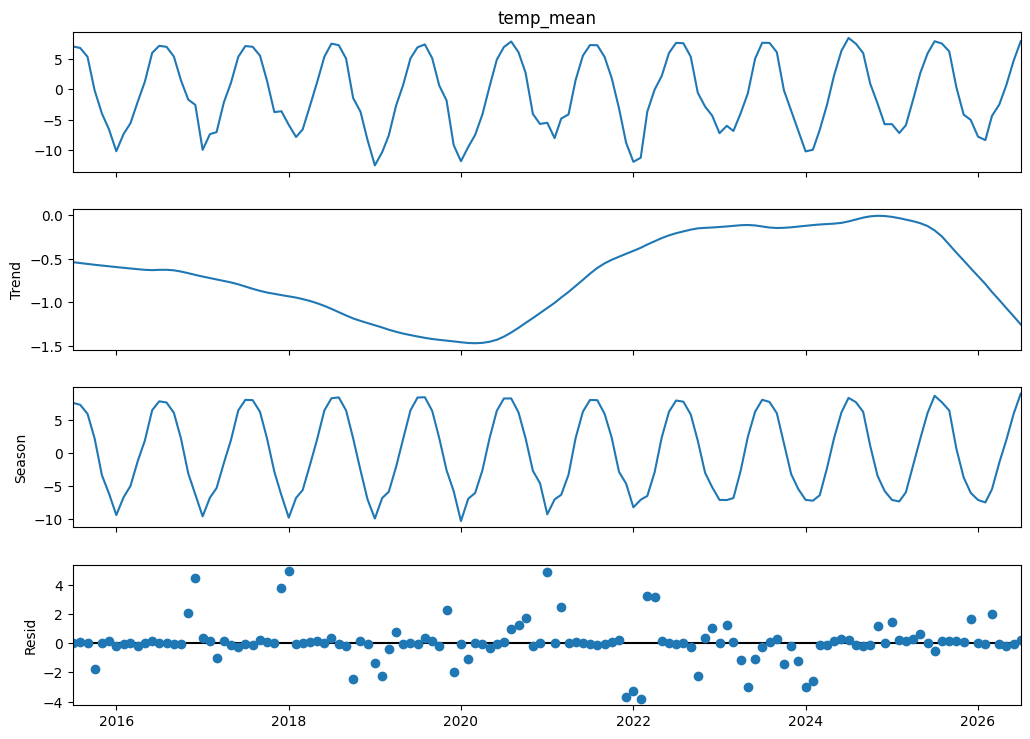

In [7]:
try:
    decomposition = stl_decomposition(features, 'temp_mean')
    stl_figure = decomposition.plot()
    stl_figure.set_size_inches(11, 8)
    stl_figure.savefig(
        SETTINGS.output_charts / 'temperature_stl_decomposition.png',
        dpi=200, bbox_inches='tight',
    )
    display(stl_figure)
except ValueError as exc:
    print(exc)


## PELT change-point candidates
PELT uses an L2 level-shift model, a minimum 12-month segment, and a documented logarithmic penalty. Results are penalty-dependent diagnostics, not confidence intervals or event precursors. Variables with internal gaps are skipped explicitly.

In [8]:
change_frames = []
change_errors = []
for column in ('temp_anomaly', 'PDD_adjusted', 'VV_anomaly'):
    try:
        detected = detect_change_points(analysis, column)
        change_frames.append(detected)
    except ValueError as exc:
        change_errors.append({'feature': column, 'diagnostic': str(exc)})
changes = pd.concat(change_frames, ignore_index=True) if change_frames else pd.DataFrame()
diagnostics = pd.concat(
    [changes, pd.DataFrame(change_errors)], ignore_index=True, sort=False
)
diagnostics.to_csv(SETTINGS.output_tables / 'change_point_diagnostics.csv', index=False)
display(diagnostics)
if not changes.empty and (changes['feature'] == 'temp_anomaly').any():
    temperature_changes = changes.loc[changes['feature'] == 'temp_anomaly']
    change_figure = plot_change_points(
        analysis, 'temp_anomaly', temperature_changes,
        SETTINGS.output_charts / 'temperature_change_points.png',
    )
    display(change_figure)


,feature,diagnostic
0,VV_anomaly,Change-point analysis skipped for VV_anomaly: ...


## V2 autocorrelation, quality sensitivity, and optional regression
The trend table now contains lag-1 autocorrelation, Ljung–Box, and Hamed–Rao modified Mann–Kendall diagnostics. Lagged correlations include Benjamini–Hochberg adjusted p-values. The optional snow regression reports VIF before interpretation.

In [9]:
if 'sentinel2_quality_status' in features:
    quality_frame = analysis.merge(
        features[['date', 'sentinel2_quality_status']], on='date', how='left'
    )
    quality_sensitivity = trend_quality_sensitivity(
        quality_frame, 'snow_fraction_anomaly',
        'sentinel2_quality_status',
    )
    quality_sensitivity.to_csv(
        SETTINGS.output_tables / 'trend_quality_sensitivity.csv', index=False
    )
    display(quality_sensitivity)
try:
    regression_coefficients, regression_diagnostics = (
        multivariate_snow_regression(analysis)
    )
    regression_coefficients.to_csv(
        SETTINGS.output_tables / 'snow_climate_regression.csv', index=False
    )
    display(regression_coefficients)
    display(pd.DataFrame([regression_diagnostics]))
except ValueError as exc:
    print('Optional snow regression skipped:', exc)


,term,coefficient,hac_se,p_value
0,const,0.014521,0.018965,0.443870
1,temp_anomaly,-0.053395,0.011459,0.000003
2,PDD_adjusted,-0.000717,0.000805,0.373210
3,precip_anomaly,0.024480,0.009984,0.014211


,n,r_squared,maximum_vif,vif_temp_anomaly,vif_PDD_adjusted,vif_precip_anomaly
0,103,0.414718,1.248664,1.248664,1.240252,1.092448


## Interpretation checkpoint
A small raw or FDR-adjusted p-value does not identify a physical cause. Review slope magnitude, uncertainty, completeness, autocorrelation, multiple testing, sensor changes, VIF, and spatial evidence together. These results identify statistical associations for investigation; they do not demonstrate collapse prediction or causality.